# Notebook 01 — Data Pipeline
**Member 1: Data Engineer & Repository Manager**

This notebook covers every step of the data ingestion pipeline:
1. Load the raw Hillstrom CSV and validate its integrity
2. Explore the dataset visually before touching it
3. Engineer features (One-Hot Encoding + raw numerics)
4. Create a stratified 80/20 train/test split
5. Run the propensity score overlap check
6. Save the processed CSV for downstream members

**Run this notebook FIRST before any other notebook.**
All other members import from `src/data_loader.py` which this notebook validates.

In [48]:
import sys
import os

# This adds the parent directory (Causal-Uplift-EBM) to Python's search path
sys.path.append(os.path.abspath(os.path.join('..')))

# Now you can import from src
from src.data_loader import load_and_preprocess_hillstrom

## 0 · Environment setup

In [49]:
# Add the repo root to Python path so we can import from src/
# This one line replaces having to install the project as a package
import sys, os
sys.path.insert(0, os.path.abspath('..'))

# Install dependencies if running on a fresh Colab instance
# Uncomment the line below if needed:
# !pip install pandas numpy scikit-learn matplotlib --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Our own modules
from src.config import (
    GLOBAL_SEED, RAW_DATA_PATH, PROCESSED_DATA_PATH,
    RESULTS_DIR, TREATMENT_COL, TARGET_COL,
    CATEGORICAL_COLS, NUMERICAL_COLS, TEST_SIZE
)

os.makedirs(RESULTS_DIR, exist_ok=True)

print('Python path set. Imports successful.')
print(f'Raw data expected at : {os.path.abspath(RAW_DATA_PATH)}')

Python path set. Imports successful.
Raw data expected at : /home/shaurya/Causal-Uplift-EBM/data/hillstrom.csv


## 1 · Load raw data & integrity checks

In [50]:
# ── Load the CSV ─────────────────────────────────────────────────────────────
# If this cell fails with FileNotFoundError, download the Hillstrom dataset
# from: http://www.minethatdata.com/Kevin_Hillstrom_MineThatData_E-MailAnalytics_DataMiningChallenge_2008.03.20.csv
# and place it at:  data/hillstrom.csv

df_raw = pd.read_csv(RAW_DATA_PATH)

print('=== Raw dataset loaded ===')
print(f'Shape          : {df_raw.shape}   (rows, columns)')
print(f'Memory usage   : {df_raw.memory_usage(deep=True).sum() / 1e6:.2f} MB')
print()
print('Column names   :', list(df_raw.columns))
print()
df_raw.head()

=== Raw dataset loaded ===
Shape          : (64000, 12)   (rows, columns)
Memory usage   : 21.00 MB

Column names   : ['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel', 'segment', 'visit', 'conversion', 'spend']



,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


In [51]:
# ── Dimensionality check ──────────────────────────────────────────────────────
# The Hillstrom dataset should have exactly 64,000 rows.
# If this assertion fails, you have the wrong file.

assert df_raw.shape[0] == 64_000, (
    f'Expected 64,000 rows — got {df_raw.shape[0]}.'
    ' Check you downloaded the correct Hillstrom dataset.'
)
print('Row count check  : PASSED (64,000 rows confirmed)')

Row count check  : PASSED (64,000 rows confirmed)


In [52]:
# ── Data types ────────────────────────────────────────────────────────────────
print('Column data types:')
print(df_raw.dtypes)
print()

# ── Missing values ────────────────────────────────────────────────────────────
null_counts = df_raw.isnull().sum()
print('Missing values per column:')
print(null_counts)

if null_counts.sum() == 0:
    print('\nMissing value check : PASSED (no nulls found)')
else:
    print(f'\nWARNING: {null_counts.sum()} missing values found.')
    print('These will be dropped in the pipeline.')

Column data types:
recency              int64
history_segment     object
history            float64
mens                 int64
womens               int64
zip_code            object
newbie               int64
channel             object
segment             object
visit                int64
conversion           int64
spend              float64
dtype: object

Missing values per column:
recency            0
history_segment    0
history            0
mens               0
womens             0
zip_code           0
newbie             0
channel            0
segment            0
visit              0
conversion         0
spend              0
dtype: int64

Missing value check : PASSED (no nulls found)


In [53]:
# ── Treatment column validation ───────────────────────────────────────────────
# The raw 'segment' column has three values.
# We will merge 'Mens E-Mail' and 'Womens E-Mail' into treatment=1.

print(f"Unique values in '{TREATMENT_COL}' column:")
print(df_raw[TREATMENT_COL].value_counts())
print()

# ── Target variable validation ────────────────────────────────────────────────
print(f"Target column '{TARGET_COL}' distribution:")
print(df_raw[TARGET_COL].value_counts())
print(f'Positive rate: {df_raw[TARGET_COL].mean():.3f} ({df_raw[TARGET_COL].mean()*100:.1f}%)')
print()
print('Secondary target (conversion) distribution:')
print(df_raw['conversion'].value_counts())
print(f'Positive rate: {df_raw["conversion"].mean():.3f} ({df_raw["conversion"].mean()*100:.1f}%)')
print()
print('NOTE: conversion rate is ~1% — very imbalanced.')
print('We use visit (~15%) as our primary target for this project.')

Unique values in 'segment' column:
segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64

Target column 'visit' distribution:
visit
0    54606
1     9394
Name: count, dtype: int64
Positive rate: 0.147 (14.7%)

Secondary target (conversion) distribution:
conversion
0    63422
1      578
Name: count, dtype: int64
Positive rate: 0.009 (0.9%)

NOTE: conversion rate is ~1% — very imbalanced.
We use visit (~15%) as our primary target for this project.


## 2 · Exploratory data analysis (EDA)

In [54]:
# ── Summary statistics ────────────────────────────────────────────────────────
# Look at this before engineering features.
# Any surprises here (e.g. extreme outliers in 'recency') should be documented.
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
recency,64000.0,NaN,NaN,NaN,5.763734,3.507592,1.0,2.0,6.0,9.0,12.0
history_segment,64000,7,1) $0 - $100,22970,NaN,NaN,NaN,NaN,NaN,NaN,NaN
history,64000.0,NaN,NaN,NaN,242.085656,256.158608,29.99,64.66,158.11,325.6575,3345.93
mens,64000.0,NaN,NaN,NaN,0.551031,0.497393,0.0,0.0,1.0,1.0,1.0
womens,64000.0,NaN,NaN,NaN,0.549719,0.497526,0.0,0.0,1.0,1.0,1.0
zip_code,64000,3,Surburban,28776,NaN,NaN,NaN,NaN,NaN,NaN,NaN
newbie,64000.0,NaN,NaN,NaN,0.50225,0.499999,0.0,0.0,1.0,1.0,1.0
channel,64000,3,Web,28217,NaN,NaN,NaN,NaN,NaN,NaN,NaN
segment,64000,3,Womens E-Mail,21387,NaN,NaN,NaN,NaN,NaN,NaN,NaN
visit,64000.0,NaN,NaN,NaN,0.146781,0.35389,0.0,0.0,0.0,0.0,1.0


In [55]:
# ── Create clean binary treatment column for EDA ──────────────────────────────
df_eda = df_raw.copy()
df_eda['treatment'] = (df_eda[TREATMENT_COL] != 'No E-Mail').astype(int)

print('Treatment flag distribution after binarisation:')
print(df_eda['treatment'].value_counts())
print(f'Treatment rate: {df_eda["treatment"].mean():.3f}')

Treatment flag distribution after binarisation:
treatment
1    42694
0    21306
Name: count, dtype: int64
Treatment rate: 0.667


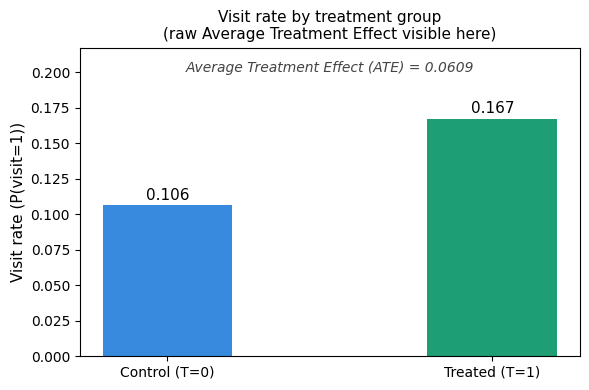

ATE (raw): treated visit rate − control visit rate = 0.0609


In [56]:
# ── Plot 1: Target rate by treatment group ────────────────────────────────────
# This is the most important EDA plot — it shows there IS a treatment effect.
# If treated and control conversion rates were identical, uplift modelling
# would have nothing to estimate.

visit_by_treatment = df_eda.groupby('treatment')[TARGET_COL].mean()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    ['Control (T=0)', 'Treated (T=1)'],
    visit_by_treatment.values,
    color=['#378ADD', '#1D9E75'],
    width=0.4
)
ax.set_ylabel('Visit rate (P(visit=1))', fontsize=11)
ax.set_title('Visit rate by treatment group\n(raw Average Treatment Effect visible here)', fontsize=11)
ax.set_ylim(0, visit_by_treatment.max() * 1.3)

# Annotate bars with exact values
for bar, val in zip(bars, visit_by_treatment.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.002,
        f'{val:.3f}',
        ha='center', va='bottom', fontsize=11, fontweight='500'
    )

ate = visit_by_treatment[1] - visit_by_treatment[0]
ax.text(0.5, 0.92, f'Average Treatment Effect (ATE) = {ate:.4f}',
        transform=ax.transAxes, ha='center', fontsize=10,
        style='italic', color='#444')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'eda_visit_rate_by_treatment.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f'ATE (raw): treated visit rate − control visit rate = {ate:.4f}')

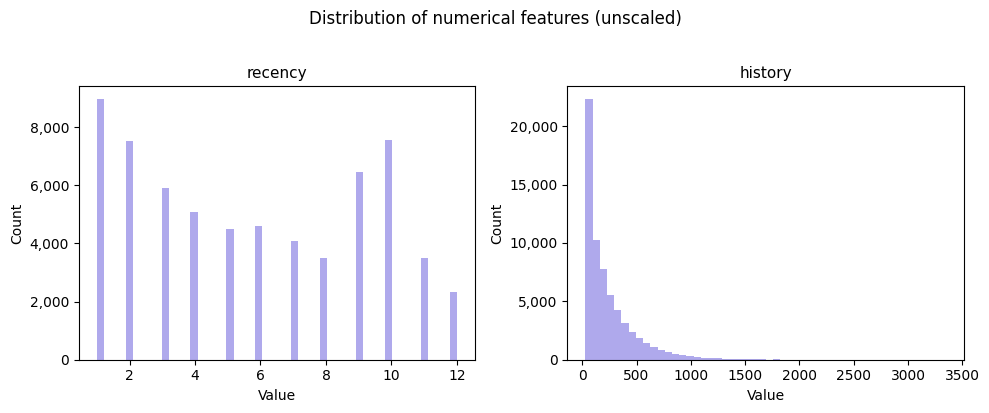

In [57]:
# ── Plot 2: Distribution of numerical features ────────────────────────────────
# Check for skewness, outliers, or unexpected ranges.
# Remember: we do NOT scale these — EBM learns its own step functions.

fig, axes = plt.subplots(1, len(NUMERICAL_COLS), figsize=(10, 4))
if len(NUMERICAL_COLS) == 1:
    axes = [axes]

for ax, col in zip(axes, NUMERICAL_COLS):
    ax.hist(df_eda[col].dropna(), bins=50, color='#AFA9EC', edgecolor='none')
    ax.set_title(f'{col}', fontsize=11)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Distribution of numerical features (unscaled)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'eda_numerical_distributions.png'), dpi=300, bbox_inches='tight')
plt.show()

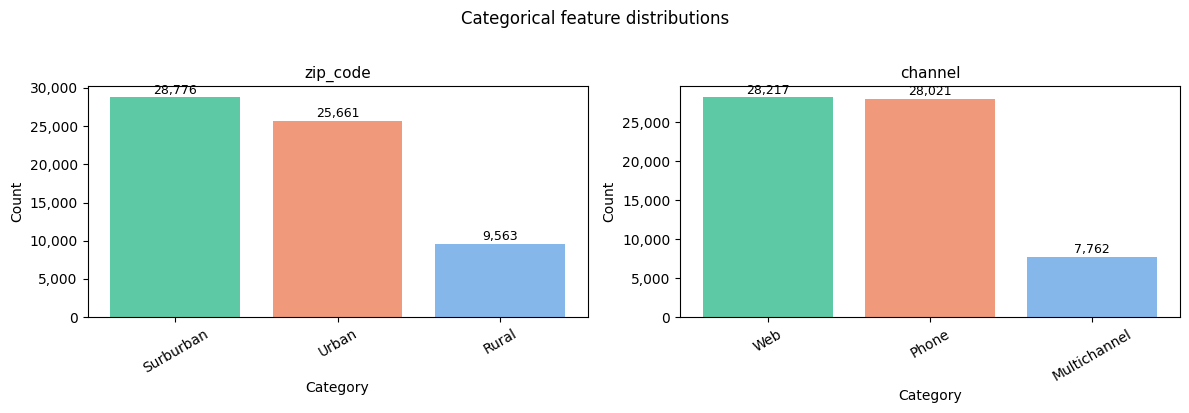

In [58]:
# ── Plot 3: Categorical feature distributions ─────────────────────────────────
# Understand class balance in categorical columns BEFORE encoding.
# Rare categories become rare one-hot columns — not a problem for
# tree-based models but worth documenting.

fig, axes = plt.subplots(1, len(CATEGORICAL_COLS), figsize=(12, 4))
if len(CATEGORICAL_COLS) == 1:
    axes = [axes]

colors = ['#5DCAA5', '#F0997B', '#85B7EB', '#EF9F27', '#ED93B1']

for ax, col in zip(axes, CATEGORICAL_COLS):
    counts = df_eda[col].value_counts()
    ax.bar(counts.index, counts.values,
           color=colors[:len(counts)], edgecolor='none')
    ax.set_title(f'{col}', fontsize=11)
    ax.set_xlabel('Category')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    # Annotate bars
    for i, (cat, val) in enumerate(counts.items()):
        ax.text(i, val + 100, f'{val:,}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Categorical feature distributions', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'eda_categorical_distributions.png'), dpi=300, bbox_inches='tight')
plt.show()

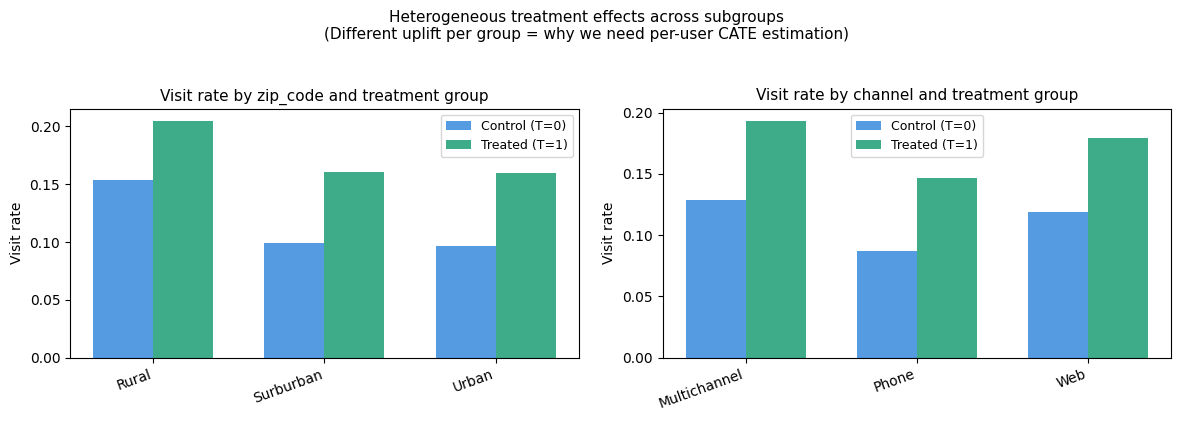

Key insight: if treatment effect were the same for everyone,
all bars of the same color would be equal height.
They are NOT — this justifies the individual CATE estimation approach.


In [59]:
# ── Plot 4: Visit rate broken down by zip_code and channel ───────────────────
# This plot is gold for the viva — it shows HETEROGENEOUS treatment effects
# across subgroups, which is exactly why we need uplift modelling
# instead of a single Average Treatment Effect.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col in zip(axes, CATEGORICAL_COLS):
    pivot = df_eda.groupby([col, 'treatment'])[TARGET_COL].mean().unstack()
    pivot.columns = ['Control (T=0)', 'Treated (T=1)']

    x = np.arange(len(pivot))
    width = 0.35
    ax.bar(x - width/2, pivot['Control (T=0)'], width,
           label='Control (T=0)', color='#378ADD', alpha=0.85)
    ax.bar(x + width/2, pivot['Treated (T=1)'], width,
           label='Treated (T=1)', color='#1D9E75', alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(pivot.index, rotation=20, ha='right')
    ax.set_ylabel('Visit rate')
    ax.set_title(f'Visit rate by {col} and treatment group', fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle(
    'Heterogeneous treatment effects across subgroups\n'
    '(Different uplift per group = why we need per-user CATE estimation)',
    fontsize=11, y=1.04
)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'eda_heterogeneous_effects.png'), dpi=300, bbox_inches='tight')
plt.show()
print('Key insight: if treatment effect were the same for everyone,')
print('all bars of the same color would be equal height.')
print('They are NOT — this justifies the individual CATE estimation approach.')

## 3 · Run the full data pipeline

In [60]:
# ── Run Member 1's data_loader.py ─────────────────────────────────────────────
# This single call does: load → validate → encode → stratified split → save CSV
# Study the output carefully — every print statement documents a decision.

from src.data_loader import load_and_preprocess_hillstrom, check_propensity_overlap

X_train, X_test, y_train, y_test, t_train, t_test = load_and_preprocess_hillstrom(
    filepath=RAW_DATA_PATH,
    save=True    # writes hillstrom_processed.csv to data/
)

[1/5] Loading data from: /home/shaurya/Causal-Uplift-EBM/src/../data/hillstrom.csv
      Shape: (64000, 12)
      No missing values found. Good.
      Treatment distribution:
treatment
1    42694
0    21306
Name: count, dtype: int64
      Target ('visit') distribution:
visit
0    54606
1     9394
Name: count, dtype: int64
[2/5] Engineering features...
      Feature matrix columns after encoding: ['recency', 'history_segment', 'history', 'mens', 'womens', 'newbie', 'segment', 'visit', 'conversion', 'spend', 'treatment', 'zip_code_Surburban', 'zip_code_Urban', 'channel_Phone', 'channel_Web']
[5/5] Saving processed data to: /home/shaurya/Causal-Uplift-EBM/src/../data/hillstrom_processed.csv
      Done.
[3/5] Creating stratified 80/20 train/test split...
      Train size: 51,200  |  Test size: 12,800
      Train treatment rate: 0.667  |  Test: 0.667
      Train target rate:    0.147  |  Test: 0.147

=== Data pipeline complete ===
  X_train shape : (51200, 11)
  X_test shape  : (12800, 11)


In [61]:
# ── Verify the split dimensions ───────────────────────────────────────────────
print('=== Post-split verification ===')
print(f'X_train : {X_train.shape}   X_test : {X_test.shape}')
print(f'y_train : {y_train.shape}   y_test : {y_test.shape}')
print(f't_train : {t_train.shape}   t_test : {t_test.shape}')
print()

# Check stratification worked: treatment rate and target rate should be
# almost identical between train and test
print('=== Stratification quality check ===')
print(f'Treatment rate  — train: {t_train.mean():.4f}  test: {t_test.mean():.4f}  (should match)')
print(f'Visit rate      — train: {y_train.mean():.4f}  test: {y_test.mean():.4f}  (should match)')
print()

# Check the four strata are all represented
for t_val, y_val in [(0,0),(0,1),(1,0),(1,1)]:
    n_train = ((t_train == t_val) & (y_train == y_val)).sum()
    n_test  = ((t_test  == t_val) & (y_test  == y_val)).sum()
    print(f'  Stratum T={t_val}, y={y_val}  →  train: {n_train:,}   test: {n_test:,}')

=== Post-split verification ===
X_train : (51200, 11)   X_test : (12800, 11)
y_train : (51200,)   y_test : (12800,)
t_train : (51200,)   t_test : (12800,)

=== Stratification quality check ===
Treatment rate  — train: 0.6671  test: 0.6671  (should match)
Visit rate      — train: 0.1468  test: 0.1467  (should match)

  Stratum T=0, y=0  →  train: 15,235   test: 3,809
  Stratum T=0, y=1  →  train: 1,810   test: 452
  Stratum T=1, y=0  →  train: 28,449   test: 7,113
  Stratum T=1, y=1  →  train: 5,706   test: 1,426


In [62]:
# ── Inspect the encoded feature matrix ───────────────────────────────────────
print('Feature names after One-Hot Encoding:')
for i, col in enumerate(X_train.columns):
    print(f'  [{i:2d}] {col}')

print()
print('Sample of encoded training data:')
X_train.head(3)

Feature names after One-Hot Encoding:
  [ 0] recency
  [ 1] history_segment
  [ 2] history
  [ 3] mens
  [ 4] womens
  [ 5] newbie
  [ 6] spend
  [ 7] zip_code_Surburban
  [ 8] zip_code_Urban
  [ 9] channel_Phone
  [10] channel_Web

Sample of encoded training data:


,recency,history_segment,history,mens,womens,newbie,spend,zip_code_Surburban,zip_code_Urban,channel_Phone,channel_Web
18848,3,5) $500 - $750,547.86,0,1,1,0.0,0,1,0,0
54487,6,2) $100 - $200,171.21,0,1,0,0.0,0,1,0,1
3256,4,5) $500 - $750,588.45,0,1,1,0.0,0,0,0,1


## 4 · Propensity score overlap check

[4/5] Running propensity score overlap check...
      Propensity plot saved to: /home/shaurya/Causal-Uplift-EBM/src/../reports/propensity_overlap.png


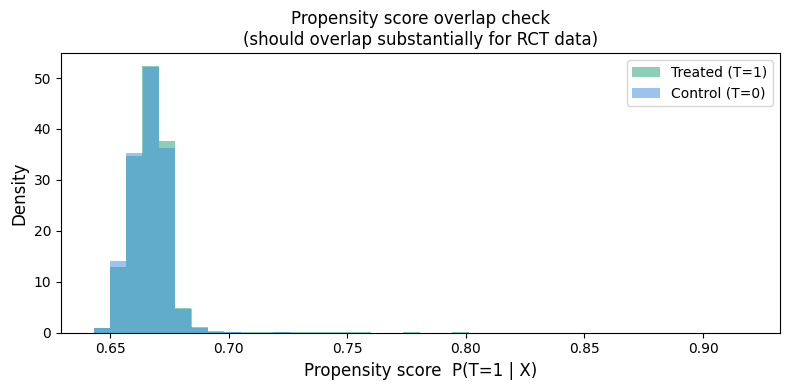

      Treated  — mean propensity: 0.667  std: 0.012
      Control  — mean propensity: 0.667  std: 0.010
      If these are very close, the overlap assumption holds. Good.

INTERPRETATION:
If the two distributions heavily overlap: overlap assumption holds. Good.
If they are separated: T-Learner extrapolates in some feature regions. Flag this.


In [63]:
# ── Why we do this check ──────────────────────────────────────────────────────
#
# The T-Learner makes a critical assumption called 'overlap' or 'positivity':
# for every feature combination X, BOTH treated AND control users must exist.
# If certain users only ever appear in the treatment group, the T-Learner's
# μ₀ model has never seen them, and τ(X) = μ₁(X) − μ₀(X) becomes an
# out-of-sample extrapolation — unreliable.
#
# We check this by fitting a logistic regression that tries to PREDICT
# treatment from features.  If the model cannot distinguish treated from
# control users (i.e. both groups have similar propensity score distributions),
# the overlap assumption holds.
#
# For Hillstrom (an RCT), we EXPECT near-perfect overlap — randomisation
# guarantees it.  This plot is the proof for the viva panel.
# Use pandas to convert strings to numbers (One-Hot Encoding)
X_train_encoded = pd.get_dummies(X_train, drop_first=True)
propensity_scores = check_propensity_overlap(
    X_train_encoded, t_train,
    save_path=os.path.join(RESULTS_DIR, 'propensity_overlap.png')
)
print()
print('INTERPRETATION:')
print('If the two distributions heavily overlap: overlap assumption holds. Good.')
print('If they are separated: T-Learner extrapolates in some feature regions. Flag this.')

## 5 · Verify processed CSV was saved

In [64]:
# ── Load back the saved CSV and verify it matches what we computed ────────────
df_processed = pd.read_csv(PROCESSED_DATA_PATH)

print(f'Processed CSV shape : {df_processed.shape}')
print(f'Saved at            : {os.path.abspath(PROCESSED_DATA_PATH)}')
print()
print('Columns in processed CSV:')
print(list(df_processed.columns))
print()
df_processed.head(3)

Processed CSV shape : (64000, 15)
Saved at            : /home/shaurya/Causal-Uplift-EBM/data/hillstrom_processed.csv

Columns in processed CSV:
['recency', 'history_segment', 'history', 'mens', 'womens', 'newbie', 'segment', 'visit', 'conversion', 'spend', 'treatment', 'zip_code_Surburban', 'zip_code_Urban', 'channel_Phone', 'channel_Web']



,recency,history_segment,history,mens,womens,newbie,segment,visit,conversion,spend,treatment,zip_code_Surburban,zip_code_Urban,channel_Phone,channel_Web
0,10,2) $100 - $200,142.44,1,0,0,Womens E-Mail,0,0,0.0,1,1,0,1,0
1,6,3) $200 - $350,329.08,1,1,1,No E-Mail,0,0,0.0,0,0,0,0,1
2,7,2) $100 - $200,180.65,0,1,1,Womens E-Mail,0,0,0.0,1,1,0,0,1


## 6 · Final deliverable summary

In [65]:
# ── Summary of everything produced by this notebook ──────────────────────────
print('=' * 55)
print('MEMBER 1 DELIVERABLES — STATUS CHECK')
print('=' * 55)

deliverables = {
    'src/config.py'                          : '../src/config.py',
    'src/data_loader.py'                     : '../src/data_loader.py',
    'data/hillstrom_processed.csv'           : PROCESSED_DATA_PATH,
    'reports/eda_visit_rate_by_treatment.png': os.path.join(RESULTS_DIR, 'eda_visit_rate_by_treatment.png'),
    'reports/eda_numerical_distributions.png': os.path.join(RESULTS_DIR, 'eda_numerical_distributions.png'),
    'reports/eda_categorical_distributions.png': os.path.join(RESULTS_DIR, 'eda_categorical_distributions.png'),
    'reports/eda_heterogeneous_effects.png'  : os.path.join(RESULTS_DIR, 'eda_heterogeneous_effects.png'),
    'reports/propensity_overlap.png'         : os.path.join(RESULTS_DIR, 'propensity_overlap.png'),
}

all_good = True
for label, path in deliverables.items():
    exists = os.path.exists(path)
    status = 'OK' if exists else 'MISSING'
    print(f'  [{status:7s}]  {label}')
    if not exists:
        all_good = False

print()
if all_good:
    print('All deliverables present. Pipeline locked.')
    print('Notify Member 2 — the data pipeline is ready.')
else:
    print('Some deliverables are missing. Re-run cells above.')

MEMBER 1 DELIVERABLES — STATUS CHECK
  [OK     ]  src/config.py
  [OK     ]  src/data_loader.py
  [OK     ]  data/hillstrom_processed.csv
  [OK     ]  reports/eda_visit_rate_by_treatment.png
  [OK     ]  reports/eda_numerical_distributions.png
  [OK     ]  reports/eda_categorical_distributions.png
  [OK     ]  reports/eda_heterogeneous_effects.png
  [OK     ]  reports/propensity_overlap.png

All deliverables present. Pipeline locked.
Notify Member 2 — the data pipeline is ready.


In [66]:
# ── Git commit reminder ───────────────────────────────────────────────────────
print('Next steps for Member 1:')
print()
print('  git add data/hillstrom_processed.csv')
print('  git add src/config.py src/data_loader.py')
print('  git add reports/*.png')
print('  git add notebooks/01_data_pipeline.ipynb')
print('  git commit -m "feat: Member 1 — data pipeline complete')
print('                 One-Hot Encoding: zip_code, channel (drop_first=True)')
print('                 Stratified split: 80/20 on T+y combined strata')
print('                 Propensity overlap check confirms RCT balance"')
print('  git push origin main')

Next steps for Member 1:

  git add data/hillstrom_processed.csv
  git add src/config.py src/data_loader.py
  git add reports/*.png
  git add notebooks/01_data_pipeline.ipynb
  git commit -m "feat: Member 1 — data pipeline complete
                 One-Hot Encoding: zip_code, channel (drop_first=True)
                 Stratified split: 80/20 on T+y combined strata
                 Propensity overlap check confirms RCT balance"
  git push origin main
